<a href="https://colab.research.google.com/github/wonkavite/NFL_Draft/blob/main/NationalFootballLeague.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np  # Library for numerical computing and array operations
import pandas as pd  # Library for handling tabular data
import matplotlib.pyplot as plt  # Library for basic data visualization
import seaborn as sns  # Library for statistical data visualization
from sklearn.preprocessing import LabelEncoder  # Encoder for converting categorical variables to numeric labels
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from sklearn.model_selection import StratifiedKFold  # Class for stratified K-fold cross-validation
from sklearn.metrics import roc_auc_score  # Metric function for computing ROC AUC
from sklearn.metrics import accuracy_score, roc_auc_score

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# If you work with Google Colaboratory, please run this as well.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/04. Competition (due Jun 12th 11AM UTC)/competition"

/content/drive/.shortcut-targets-by-id/1I5cUtwB2Pn-u8Agxb1Cc18lSRTOrdc6r/04. Competition (due Jun 12th 11AM UTC)/competition


In [8]:
from pathlib import Path

PATH = Path("/content/drive/MyDrive/04. Competition (due Jun 12th 11AM UTC)/competition/input")

train_file = PATH / "train.csv"
test_file = PATH / "test.csv"
sample_sub_file = PATH / "sample_submission.csv"

# Check if path exists
if train_file.exists() and test_file.exists() and sample_sub_file.exists():
    print("All files exist and path is correctly set.")
else:
    print("Some files are missing or path is not correctly set.")

All files exist and path is correctly set.


In [9]:
PATH = Path.cwd() / "input"

train = pd.read_csv(PATH / "train.csv")
test = pd.read_csv(PATH / "test.csv")
sample_sub = pd.read_csv(PATH / "sample_submission.csv")

print(f"train: {train.shape}, test: {test.shape}, sample_sub: {sample_sub.shape}")

train: (2781, 16), test: (696, 15), sample_sub: (696, 2)


In [10]:
# Columns with missing values
cols_with_missing = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                     'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Age']

# Create missing indicators BEFORE filling missing values
for col in cols_with_missing:
    train[col + '_missing'] = train[col].isna().astype(int)
    test[col + '_missing'] = test[col].isna().astype(int)

print("Missing indicators created!")
print(train[[col + '_missing' for col in cols_with_missing]].sum())

Missing indicators created!
Sprint_40yd_missing         145
Vertical_Jump_missing       554
Bench_Press_Reps_missing    721
Broad_Jump_missing          581
Agility_3cone_missing       970
Shuttle_missing             912
Age_missing                 435
dtype: int64


In [55]:
train.describe()

,Id,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,...,Sprint_40yd_pct,Agility_3cone_pct,Shuttle_pct,RAS,HaSS,School_Tier,Speed_Score,power_score,Best_Players,Best_Player_Type
count,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,...,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000
mean,1390.000000,2013.838907,21.997016,1.873590,109.502026,4.764079,83.394051,20.069734,291.701812,7.206435,...,0.496404,0.496404,0.496404,0.500899,22.737605,1.985976,22.855415,1.356142,0.463502,0.362819
std,802.949874,3.083247,0.886140,0.067178,20.307239,0.296900,10.111046,5.864161,22.766235,0.376452,...,0.288373,0.277357,0.277862,0.137496,3.184644,0.762062,3.081791,0.411534,0.682132,0.565468
min,0.000000,2009.000000,18.000000,1.651000,67.585263,4.220000,44.450000,2.000000,198.120000,6.280000,...,0.000000,0.000000,0.000000,0.071662,11.023437,1.000000,15.465735,0.705815,0.000000,0.000000
25%,695.000000,2011.000000,21.000000,1.828800,92.986436,4.530000,77.470000,16.000000,279.400000,6.925000,...,0.245570,0.256944,0.256962,0.415665,20.652638,1.000000,20.344189,1.042519,0.000000,0.000000
50%,1390.000000,2014.000000,22.000000,1.879600,104.779837,4.690000,84.623248,19.500000,294.640000,7.090000,...,0.487805,0.498000,0.497500,0.499209,23.027480,2.000000,22.418933,1.231400,0.000000,0.000000
75%,2085.000000,2017.000000,22.000000,1.930400,124.284309,4.950000,90.170000,24.000000,307.340000,7.390000,...,0.748691,0.735443,0.735632,0.589513,24.965911,3.000000,25.561559,1.561297,1.000000,1.000000
max,2780.000000,2019.000000,28.000000,2.082800,162.386068,6.000000,114.300000,45.000000,373.380000,9.040000,...,0.997468,0.997468,0.997468,0.889725,32.372790,3.000000,32.094675,3.159487,3.000000,2.000000


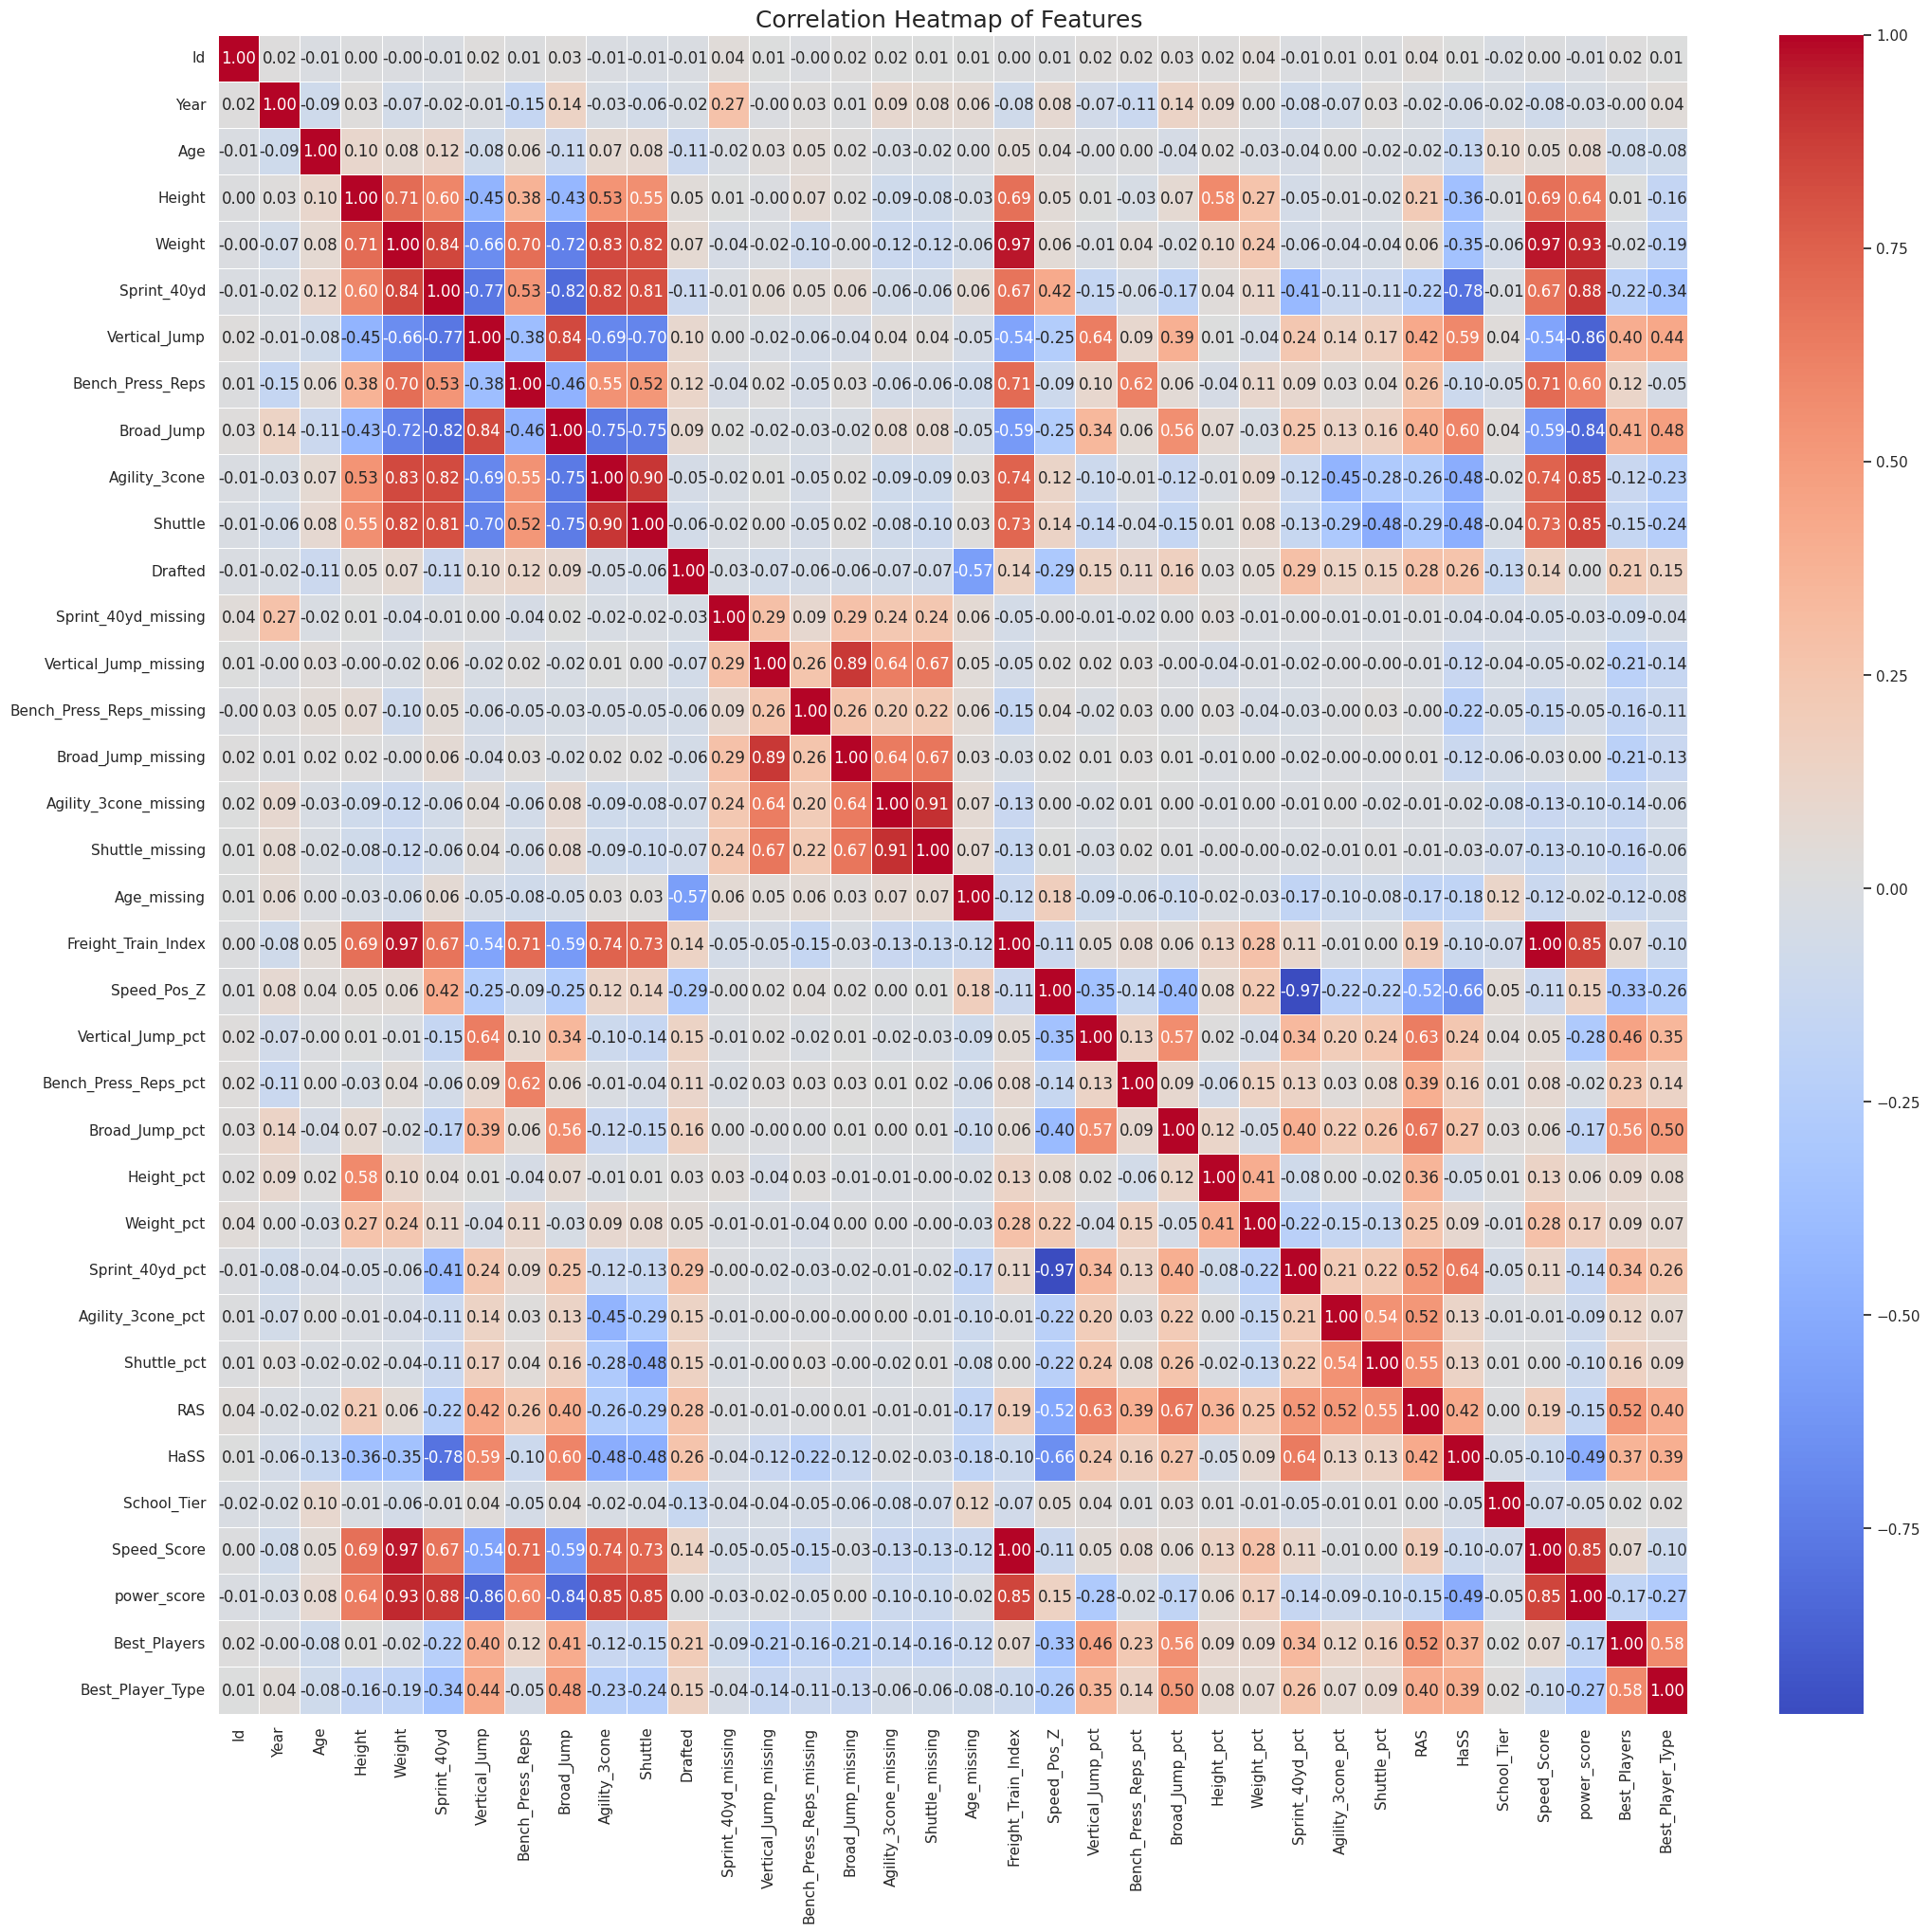

In [65]:
#A HeatMap to show correlation of my features with the target variable
plt.figure(figsize=(25, 23)) # Slightly larger figure to accommodate labels
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Features ', fontsize=18)
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.savefig('/content/drive/MyDrive/correlation_heatmap2.png') # Save the heatmap to Google Drive
plt.show()

In [13]:
#FILLING MISSING VALUES FOR AGE AS GLOBAL
age_mean = train['Age'].mean()

train['Age'] = train['Age'].fillna(age_mean)

test['Age'] = test['Age'].fillna(age_mean)

In [14]:
mean_cols = [
    'Weight',
    'Vertical_Jump',
    'Bench_Press_Reps',
    'Broad_Jump'
]

In [15]:
for col in mean_cols:

    # Learn means from TRAIN only
    position_means = train.groupby('Position')[col].mean()

    # Fill TRAIN
    train[col] = train[col].fillna(
        train['Position'].map(position_means)
    )

    # Fill TEST
    test[col] = test[col].fillna(
        test['Position'].map(position_means)
    )

    # Global fallback
    global_mean = train[col].mean()

    train[col] = train[col].fillna(global_mean)

    test[col] = test[col].fillna(global_mean)

In [16]:
median_cols = [
    'Sprint_40yd',
    'Agility_3cone',
    'Shuttle'
]

In [17]:
#train.info()

In [18]:
for col in median_cols:

    # Learn medians from TRAIN only
    position_medians = train.groupby('Position')[col].median()

    # Fill TRAIN
    train[col] = train[col].fillna(
        train['Position'].map(position_medians)
    )

    # Fill TEST
    test[col] = test[col].fillna(
        test['Position'].map(position_medians)
    )

    # Global fallback
    global_median = train[col].median()

    train[col] = train[col].fillna(global_median)

    test[col] = test[col].fillna(global_median)

In [19]:
train.isnull().sum()

,0
Id,0
Year,0
Age,0
School,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0


In [20]:
test.isnull().sum()

,0
Id,0
Year,0
Age,0
School,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0


In [21]:
train['Weight'].describe()

,Weight
count,2781.000000
mean,109.502026
std,20.307239
min,67.585263
25%,92.986436
50%,104.779837
75%,124.284309
max,162.386068


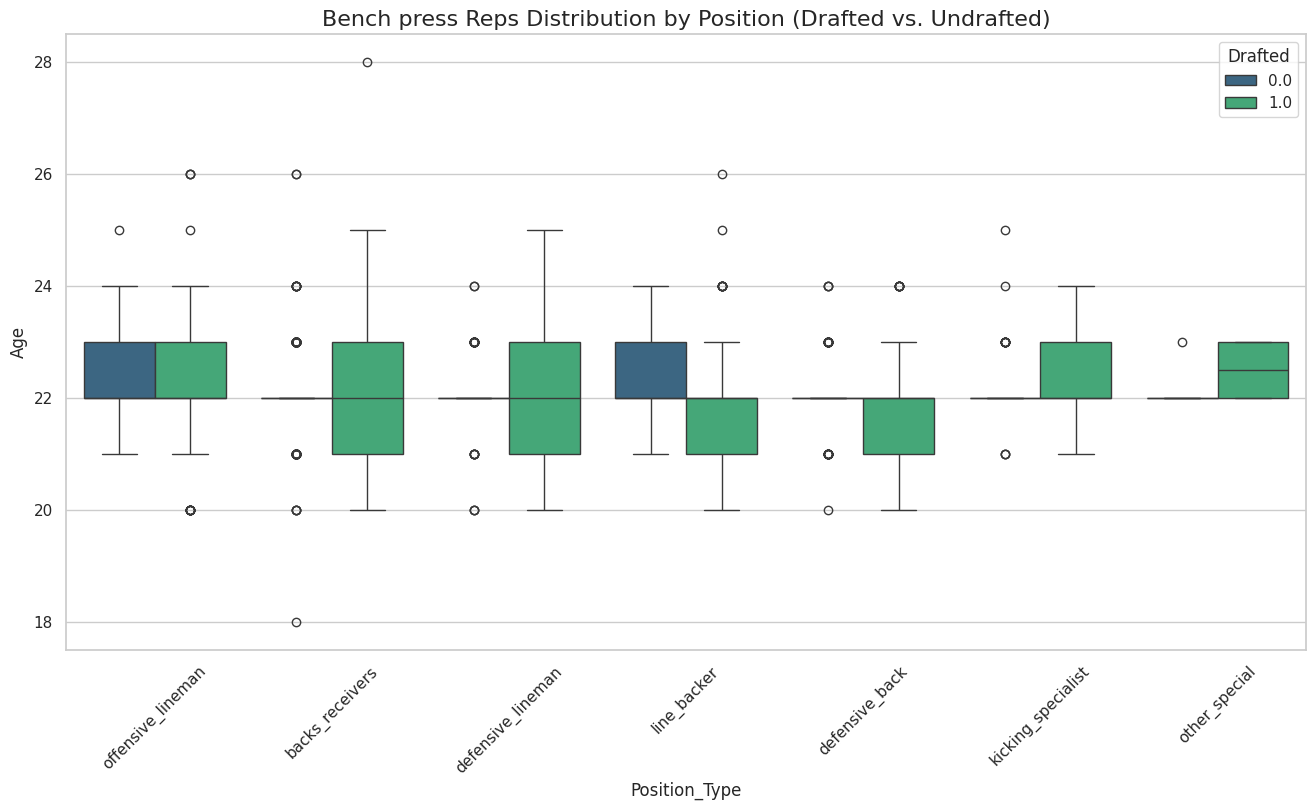

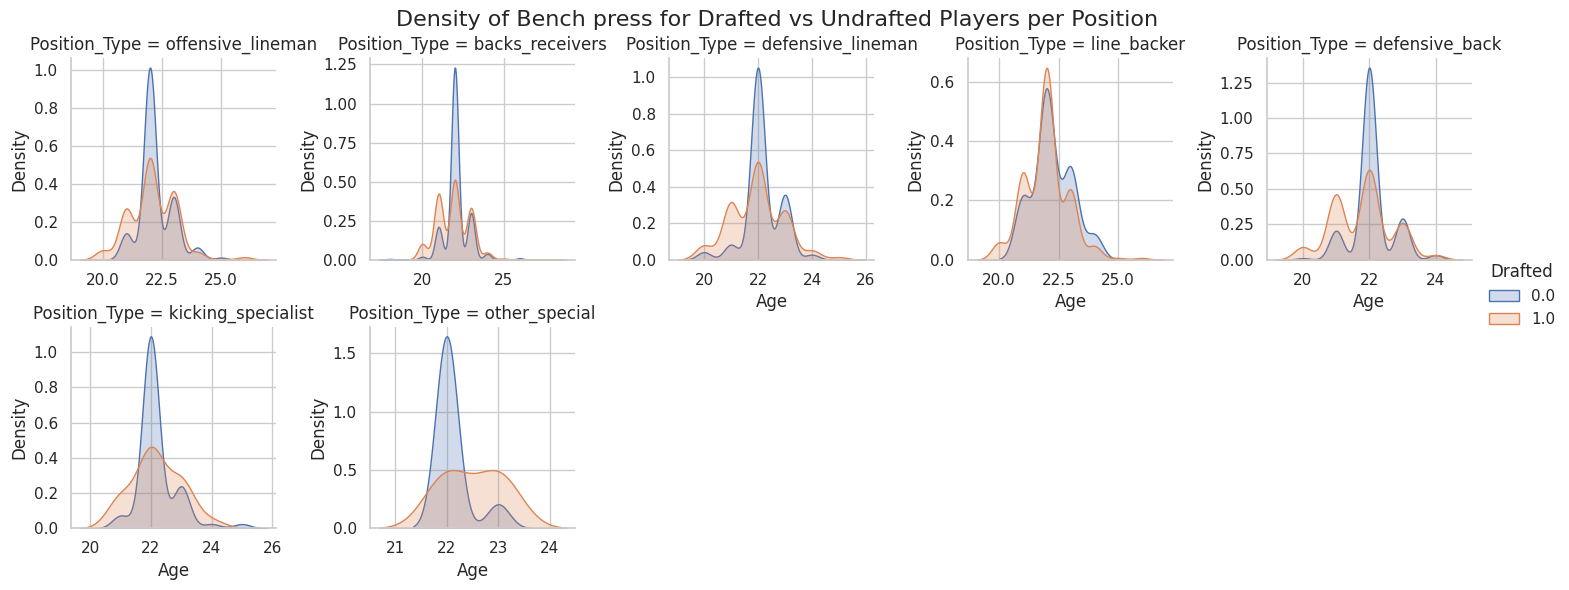

In [22]:

#EDA
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set_theme(style='whitegrid')

# 1. Boxplot: Sprint_40yd distribution by Position and Drafted status
plt.figure(figsize=(16, 8))
sns.boxplot(data=train, x='Position_Type', y='Age', hue='Drafted', palette='viridis')
plt.title('Bench press Reps Distribution by Position (Drafted vs. Undrafted)', fontsize=16)
plt.xticks(rotation=45)
plt.show()

# 2. FacetGrid: Histograms for specific comparison
g = sns.FacetGrid(train, col='Position_Type', hue='Drafted', col_wrap=5, sharex=False, sharey=False)
g.map(sns.kdeplot, 'Age', fill=True)
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Density of Bench press for Drafted vs Undrafted Players per Position', fontsize=16)
plt.show()

Player Counts per Position_type:


,Position_Type,Player_Count
0,backs_receivers,1010
1,defensive_back,541
2,offensive_lineman,435
3,defensive_lineman,391
4,line_backer,309
5,kicking_specialist,82
6,other_special,13


/tmp/ipykernel_24353/73252058.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pos_counts, x='Position_Type', y='Player_Count', palette='coolwarm')


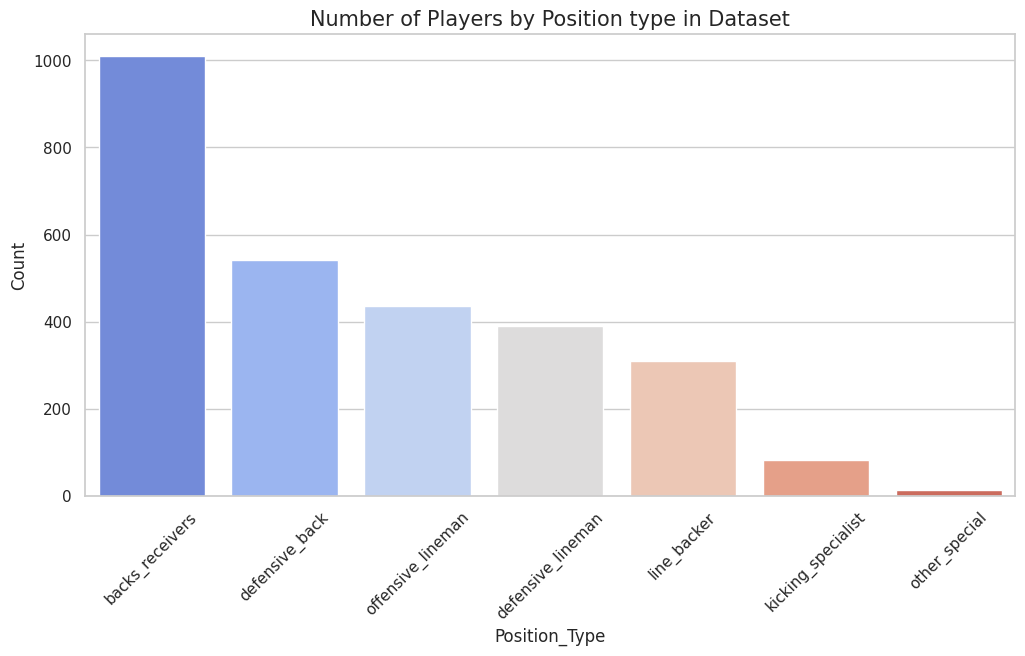

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate position counts
pos_counts = train['Position_Type'].value_counts().reset_index()
pos_counts.columns = ['Position_Type', 'Player_Count']

# Display the counts
print("Player Counts per Position_type:")
display(pos_counts)

# Visualize the distribution
plt.figure(figsize=(12, 6))
sns.barplot(data=pos_counts, x='Position_Type', y='Player_Count', palette='coolwarm')
plt.title('Number of Players by Position type in Dataset', fontsize=15)
plt.xlabel('Position_Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [24]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2781 non-null   int64  
 1   Year                      2781 non-null   int64  
 2   Age                       2781 non-null   float64
 3   School                    2781 non-null   object 
 4   Height                    2781 non-null   float64
 5   Weight                    2781 non-null   float64
 6   Sprint_40yd               2781 non-null   float64
 7   Vertical_Jump             2781 non-null   float64
 8   Bench_Press_Reps          2781 non-null   float64
 9   Broad_Jump                2781 non-null   float64
 10  Agility_3cone             2781 non-null   float64
 11  Shuttle                   2781 non-null   float64
 12  Player_Type               2781 non-null   object 
 13  Position_Type             2781 non-null   object 
 14  Position

In [25]:
#Im now doing feature engineering

In [26]:
Missing=train.isnull().any()
Total=Missing.sum()
print("Total Missing columns are",Total)

Total Missing columns are 0


In [27]:
#Feature engineering

In [28]:
train['Freight_Train_Index'] = train['Weight'] / train['Sprint_40yd']
test['Freight_Train_Index'] = test['Weight'] / test['Sprint_40yd']

In [29]:
train['Speed_Pos_Z'] = train.groupby('Position')['Sprint_40yd'].transform(lambda x: (x - x.mean()) / x.std())
test['Speed_Pos_Z'] = test.groupby('Position')['Sprint_40yd'].transform(lambda x: (x - x.mean()) / x.std())

In [30]:
#RAS
#RAS without Position target encoding
import pandas as pd

# ==========================================
# ATHLETIC METRICS
# ==========================================

metrics = {
    'Higher is Better': [
        'Vertical_Jump',
        'Bench_Press_Reps',
        'Broad_Jump',
        'Height',
        'Weight'
    ],

    'Lower is Better': [
        'Sprint_40yd',
        'Agility_3cone',
        'Shuttle'
    ]
}

# ==========================================
# CREATE POSITION-BASED RAS
# ==========================================

def create_ras(df):

    df = df.copy()

    ras_components = []

    # --------------------------------------
    # HIGHER IS BETTER
    # --------------------------------------

    for col in metrics['Higher is Better']:

        score_col = col + '_pct'

        df[score_col] = (
            df.groupby('Position')[col]
              .rank(pct=True)
        )

        ras_components.append(score_col)

    # --------------------------------------
    # LOWER IS BETTER
    # --------------------------------------

    for col in metrics['Lower is Better']:

        score_col = col + '_pct'

        df[score_col] = (
            1 -
            df.groupby('Position')[col]
              .rank(pct=True)
        )

        ras_components.append(score_col)

    # --------------------------------------
    # FINAL RAS SCORE
    # --------------------------------------

    df['RAS'] = df[ras_components].mean(axis=1)

    return df

In [31]:
train = create_ras(train)

test = create_ras(test)

In [32]:
# # HaSS - Height Adjusted Speed Score
train['HaSS'] = (train['Weight'] * 200) / (train['Sprint_40yd'] ** 4) / train['Height']
test['HaSS'] = (test['Weight'] * 200) / (test['Sprint_40yd'] ** 4) / test['Height']

In [33]:
# #School tier feature
# # Calculate how many players were drafted from each school
school_stats = train.groupby('School').agg({
    'Drafted': ['count', 'mean']
}).reset_index()

# Flatten the columns
school_stats.columns = ['School', 'Player_Count', 'Draft_Rate']

# Show the top 10 schools by volume of players
print("Top 10 Schools with most players in the dataset:")
print(school_stats.sort_values(by='Player_Count', ascending=False).head(10))
#Function
def assign_school_tier(row):
    # Tier 1: The "Elite" (High volume + >65% success)
    if row['Player_Count'] >= 40 and row['Draft_Rate'] > 0.65:
        return 1
    # Tier 2: The "Proven" (Moderate volume + >50% success)
    elif row['Player_Count'] >= 15 and row['Draft_Rate'] > 0.50:
        return 2
    # Tier 3: The "Underdogs" (Low volume or low draft success)
    else:
        return 3

# Apply this to your stats and create the mapping
school_stats['School_Tier'] = school_stats.apply(assign_school_tier, axis=1)
tier_dict = dict(zip(school_stats['School'], school_stats['School_Tier']))

# Create the new column in your main dataframes
train['School_Tier'] = train['School'].map(tier_dict).fillna(3)
test['School_Tier'] = test['School'].map(tier_dict).fillna(3)

print("Tiers assigned! Here is the count of schools in each tier:")
print(train['School_Tier'].value_counts())

Top 10 Schools with most players in the dataset:
          School  Player_Count  Draft_Rate
4        Alabama            73    0.712329
98           LSU            70    0.628571
209          USC            63    0.666667
148     Ohio St.            59    0.728814
62   Florida St.            57    0.719298
39       Clemson            57    0.736842
68       Georgia            54    0.777778
149     Oklahoma            54    0.777778
114   Miami (FL)            54    0.740741
58       Florida            50    0.740000
Tiers assigned! Here is the count of schools in each tier:
School_Tier
2    1166
1     827
3     788
Name: count, dtype: int64


In [34]:
# Speed-Strength Index
train['Speed_Score'] = (train['Sprint_40yd'] ** -1) * train['Weight']
test['Speed_Score'] = (test['Sprint_40yd'] ** -1) * test['Weight']  # Inverse 40-time weighted by weight

In [35]:
train['power_score']=train['Weight']/train['Vertical_Jump']
test['power_score']=test['Weight']/test['Vertical_Jump']

In [36]:
# Re-initialize 'Best_Players' column to 0 for both train and test
train['Best_Players'] = 0
test['Best_Players'] = 0

# --- Calculate necessary quantiles and medians from TRAIN only ---
# Sprint_40yd (Lower is better)
Q1_Sprint40_map = train.groupby('Position_Type')['Sprint_40yd'].quantile(0.25)
Median_Sprint40_map = train.groupby('Position_Type')['Sprint_40yd'].median()

# Bench_Press_Reps (Higher is better)
Q3_Bench_map = train.groupby('Position_Type')['Bench_Press_Reps'].quantile(0.75)
Median_Bench_map = train.groupby('Position_Type')['Bench_Press_Reps'].median()

# Vertical_Jump (Higher is better)
Q3_Vertical_map = train.groupby('Position_Type')['Vertical_Jump'].quantile(0.75)
Median_Vertical_map = train.groupby('Position_Type')['Vertical_Jump'].median()

# Broad_Jump (Higher is better)
Q3_Broad_map = train.groupby('Position_Type')['Broad_Jump'].quantile(0.75)
Median_Broad_map = train.groupby('Position_Type')['Broad_Jump'].median()

# Weight (Higher is better)
Q3_Weight_map = train.groupby('Position_Type')['Weight'].quantile(0.75)

# Height (Higher is better)
Median_Height_map = train.groupby('Position_Type')['Height'].median()

# Age (Specific global threshold for line_backer)
MaxAge_Linebacker = 22 # From user prompt

# Collect all thresholds in a dictionary for easier passing to apply function
thresholds = {
    'Q1_Sprint40_map': Q1_Sprint40_map.to_dict(),
    'Median_Sprint40_map': Median_Sprint40_map.to_dict(),
    'Q3_Bench_map': Q3_Bench_map.to_dict(),
    'Median_Bench_map': Median_Bench_map.to_dict(),
    'Q3_Vertical_map': Q3_Vertical_map.to_dict(),
    'Median_Vertical_map': Median_Vertical_map.to_dict(),
    'Q3_Broad_map': Q3_Broad_map.to_dict(),
    'Median_Broad_map': Median_Broad_map.to_dict(),
    'Q3_Weight_map': Q3_Weight_map.to_dict(),
    'Median_Height_map': Median_Height_map.to_dict(),
    'MaxAge': MaxAge_Linebacker
}

# Helper function to apply all conditions for a single row
def calculate_best_players_score(row, thresholds):
    score = 0
    pos_type = row['Position_Type']

    # Extract mapped thresholds for the current Position_Type, with fallbacks
    Q1_Sprint40 = thresholds['Q1_Sprint40_map'].get(pos_type, float('inf'))
    Median_Sprint40 = thresholds['Median_Sprint40_map'].get(pos_type, float('inf'))
    Q3_Bench = thresholds['Q3_Bench_map'].get(pos_type, float('-inf'))
    Median_Bench = thresholds['Median_Bench_map'].get(pos_type, float('-inf'))
    Q3_Vertical = thresholds['Q3_Vertical_map'].get(pos_type, float('-inf'))
    Median_Vertical = thresholds['Median_Vertical_map'].get(pos_type, float('-inf'))
    Q3_Broad = thresholds['Q3_Broad_map'].get(pos_type, float('-inf'))
    Median_Broad = thresholds['Median_Broad_map'].get(pos_type, float('-inf'))
    Q3_Weight = thresholds['Q3_Weight_map'].get(pos_type, float('-inf'))
    Median_Height = thresholds['Median_Height_map'].get(pos_type, float('-inf'))
    MaxAge = thresholds['MaxAge'] # Global for line_backer


    # --- backs_receivers conditions ---
    if pos_type == 'backs_receivers':
        # Condition: ((sprint_40yd<Q1 AND Bench_press_reps>Q3) OR(Weight>Q3 AND Vertical_Jump>Q3))
        cond_AB_br = (row['Sprint_40yd'] < Q1_Sprint40) and (row['Bench_Press_Reps'] > Q3_Bench)
        cond_CD_br = (row['Weight'] > Q3_Weight) and (row['Vertical_Jump'] > Q3_Vertical)

        if cond_AB_br: score += 1
        if cond_CD_br: score += 1
        # if cond_AB_br or  cond_CD_br:
        #   score += 1

        # Remaining metric: Broad_Jump (>Q3)
        if row['Broad_Jump'] > Q3_Broad: score += 1

    # --- offensive_lineman conditions ---
    elif pos_type == 'offensive_lineman':
        # Conditions: Sprint_40yd < Q1, Weight > Q3, Bench_Press_Reps > Median,
        # Vertical_Jump > Median+2, Broad_Jump > Median, Height > Median
        # Group 1: ((Sprint_40yd < Q1 AND Height > Median) OR (Weight > Q3 AND Bench_Press_Reps > Median))
        cond_AB_ol1 = (row['Sprint_40yd'] < Q1_Sprint40) and (row['Height'] > Median_Height)
        cond_CD_ol1 = (row['Weight'] > Q3_Weight) and (row['Bench_Press_Reps'] > Median_Bench)


        if cond_AB_ol1: score += 1
        if cond_CD_ol1: score += 1


        # Group 2: (Vertical_Jump > Median+2 AND Broad_Jump > Median)
        if (row['Vertical_Jump'] > (Median_Vertical + 2)) and (row['Broad_Jump'] > Median_Broad): score += 1


    # --- defensive_back conditions ---
    elif pos_type == 'defensive_back':
        # Conditions: Sprint_40yd < Median, Weight > Q3, Bench_Press_Reps > Q3,
        # Vertical_Jump > Median, Broad_Jump > Median
        # Group 1: ((Sprint_40yd < Median AND Vertical_Jump > Median) OR (Weight > Q3 AND Bench_Press_Reps > Q3))
        cond_AB_db1 = (row['Sprint_40yd'] < Median_Sprint40) and (row['Vertical_Jump'] > Median_Vertical)
        cond_CD_db1 = (row['Weight'] > Q3_Weight) and (row['Bench_Press_Reps'] > Q3_Bench)


        if cond_AB_db1: score += 1
        if cond_CD_db1: score += 1


        # Remaining metric: Broad_Jump (>Median)
        if row['Broad_Jump'] > Median_Broad:
          score += 1


    # --- defensive_lineman conditions ---
    elif pos_type == 'defensive_lineman':
        # Conditions: Sprint_40yd < Median, Weight > Q3, Bench_Press_Reps > Q3,
        # Vertical_Jump > Q3, Broad_Jump > Q3
        # Group 1: ((Sprint_40yd < Median AND Vertical_Jump > Q3) OR (Weight > Q3 AND Bench_Press_Reps > Q3))
        cond_AB_dl1 = (row['Sprint_40yd'] < Median_Sprint40) and (row['Vertical_Jump'] > Q3_Vertical)
        cond_CD_dl1 = (row['Weight'] > Q3_Weight) and (row['Bench_Press_Reps'] > Q3_Bench)


        if cond_AB_dl1: score += 1
        if cond_CD_dl1: score += 1

        # Remaining metric: Broad_Jump (>Q3)
        if row['Broad_Jump'] > Q3_Broad:
          score += 1


    # --- line_backer conditions ---
    elif pos_type == 'line_backer':
        # Conditions: Sprint_40yd < Median, Weight > Q3, Bench_Press_Reps > Median,
        # Vertical_Jump > Median, Broad_Jump > Median, Age < MaxAge
        # Group 1: ((Sprint_40yd < Median AND Age < MaxAge) OR (Weight > Q3 AND Bench_Press_Reps > Median))
        cond_AB_lb1 = (row['Sprint_40yd'] < Median_Sprint40) and (row['Age'] < MaxAge)
        cond_CD_lb1 = (row['Weight'] > Q3_Weight) and (row['Bench_Press_Reps'] > Median_Bench)

        if cond_AB_lb1: score += 1
        if cond_CD_lb1: score += 1

        # Group 2: (Vertical_Jump > Median AND Broad_Jump > Median)
        if (row['Vertical_Jump'] > Median_Vertical) and (row['Broad_Jump'] > Median_Broad): score += 1

    return score

# Apply the function to create the 'Best_Players' feature for both train and test
print("Applying detailed 'Best_Players' conditions to train data...")
train['Best_Players'] = train.apply(lambda row: calculate_best_players_score(row, thresholds), axis=1)

print("Applying detailed 'Best_Players' conditions to test data...")
test['Best_Players'] = test.apply(lambda row: calculate_best_players_score(row, thresholds), axis=1)

print("\n'Best_Players' feature created/updated for both train and test data based on new detailed rules.")
print("\nTrain 'Best_Players' distribution:")
display(train['Best_Players'].value_counts().sort_index())
print("\nTest 'Best_Players' distribution:")
display(test['Best_Players'].value_counts().sort_index())

# Display head of train with new feature for verification
print("\nTrain DataFrame head with 'Best_Players' feature (detailed rules):")
display(train[['Position_Type', 'Sprint_40yd', 'Bench_Press_Reps', 'Vertical_Jump', 'Broad_Jump', 'Weight', 'Height', 'Age', 'Best_Players']].head())

Applying detailed 'Best_Players' conditions to train data...
Applying detailed 'Best_Players' conditions to test data...

'Best_Players' feature created/updated for both train and test data based on new detailed rules.

Train 'Best_Players' distribution:


,count
Best_Players,
0,1778
1,732
2,256
3,15



Test 'Best_Players' distribution:


,count
Best_Players,
0,460
1,184
2,51
3,1



Train DataFrame head with 'Best_Players' feature (detailed rules):


,Position_Type,Sprint_40yd,Bench_Press_Reps,Vertical_Jump,Broad_Jump,Weight,Height,Age,Best_Players
0,offensive_lineman,5.39,29.00000,59.69,251.46,140.160042,1.9050,21.0,0
1,backs_receivers,4.31,16.00000,101.60,332.74,87.089735,1.8288,24.0,1
2,backs_receivers,4.51,10.00000,91.44,309.88,92.986436,1.8542,21.0,1
3,defensive_lineman,5.09,39.00000,76.20,254.00,148.778297,1.9304,21.0,1
4,backs_receivers,4.64,14.52443,78.74,281.94,92.079251,1.8796,21.0,0


In [37]:
correlation = train['Best_Players'].corr(train['Drafted'])
print(f"Pearson correlation between 'Best_Players' and 'Drafted': {correlation:.4f}")

Pearson correlation between 'Best_Players' and 'Drafted': 0.2057


In [38]:
# Re-initialize 'Best_Player_Type' column to 0 for both train and test
train['Best_Player_Type'] = 0
test['Best_Player_Type'] = 0

# --- Calculate necessary quantiles and medians from TRAIN only ---
# Sprint40 (Lower is better)
Q1_Sprint40_mapp = train.groupby('Player_Type')['Sprint_40yd'].quantile(0.25)


# Bench_Press_Reps (Higher is better)
Q3_Bench_mapp = train.groupby('Player_Type')['Bench_Press_Reps'].quantile(0.75)


# Vertical_Jump (Higher is better)
Q3_Vertical_mapp = train.groupby('Player_Type')['Vertical_Jump'].quantile(0.75)


# Broad_Jump (Higher is better)
Q3_Broad_mapp = train.groupby('Player_Type')['Broad_Jump'].quantile(0.75)


# Weight (Higher is better)
Q3_Weight_mapp = train.groupby('Player_Type')['Weight'].quantile(0.75) # Corrected: Group by Player_Type

# Height (Higher is better)
Q3_Height_mapp = train.groupby('Player_Type')['Height'].quantile(0.75) # Corrected: Group by Player_Type

thresholds = {
    'Q1_Sprint40_map': Q1_Sprint40_mapp.to_dict(),

    'Q3_Bench_map': Q3_Bench_mapp.to_dict(),

    'Q3_Vertical_map': Q3_Vertical_mapp.to_dict(),

    'Q3_Broad_map': Q3_Broad_mapp.to_dict(),

    'Q3_Weight_map': Q3_Weight_mapp.to_dict(),
    'Q3_Height_map': Q3_Height_mapp.to_dict(),

}

# Helper function to apply all conditions for a single row
def calculate_best_players_type_score(row, thresholds):
    score = 0
    player_type = row['Player_Type'] # Corrected: Use Player_Type

    # Extract mapped thresholds for the current Player_Type, with fallbacks
    Q1_Sprint40 = thresholds['Q1_Sprint40_map'].get(player_type, float('inf')) # Corrected: Use player_type

    Q3_Bench = thresholds['Q3_Bench_map'].get(player_type, float('-inf')) # Corrected: Use player_type

    Q3_Vertical = thresholds['Q3_Vertical_map'].get(player_type, float('-inf')) # Corrected: Use player_type

    Q3_Broad = thresholds['Q3_Broad_map'].get(player_type, float('-inf')) # Corrected: Use player_type

    Q3_Weight = thresholds['Q3_Weight_map'].get(player_type, float('-inf')) # Corrected: Use player_type
    Q3_Height = thresholds['Q3_Height_map'].get(player_type, float('-inf')) # Corrected: Use player_type



    # ---  offensive conditions ---
    if player_type == 'offense': # Condition now correctly checks Player_Type
        # Condition: ((sprint_40yd<Q1 AND Bench_press_reps>Q3) OR(Weight>Q3 AND Vertical_Jump>Q3))
        cond_ABX_br = (row['Sprint_40yd'] < Q1_Sprint40) and (row['Bench_Press_Reps'] > Q3_Bench)
        cond_CDX_br = (row['Weight'] > Q3_Weight) and (row['Vertical_Jump'] > Q3_Vertical)

        if cond_ABX_br: score += 1
        if cond_CDX_br: score += 1


        # Remaining metric: Broad_Jump (>Q3)
        if row['Broad_Jump'] > Q3_Broad: score += 1

    # --- defensive conditions ---
    elif player_type == 'defense': # Condition now correctly checks Player_Type
        # Conditions: Sprint_40yd < Q1, Weight > Q3, Bench_Press_Reps > Median,
        # Vertical_Jump > Median+2, Broad_Jump > Median, Height > Median
        # Group 1: ((Sprint_40yd < Q1 AND Height > Median) OR (Weight > Q3 AND Bench_Press_Reps > Median))
        cond_ABX_ol1 = (row['Sprint_40yd'] < Q1_Sprint40) and (row['Vertical_Jump'] > Q3_Vertical)
        cond_CDX_ol1 = (row['Weight'] > Q3_Weight) and (row['Bench_Press_Reps'] > Q3_Bench)


        if cond_ABX_ol1: score += 1
        if cond_CDX_ol1: score += 1


        # Group 2: (Vertical_Jump > Median+2 AND Broad_Jump > Median)
        if row['Broad_Jump'] > Q3_Broad: score += 1




    return score

# Apply the function to create the 'Best_Players' feature for both train and test
print("Applying detailed 'Best_Player_Type' conditions to train data...")
train['Best_Player_Type'] = train.apply(lambda row: calculate_best_players_type_score(row, thresholds), axis=1)

print("Applying detailed 'Best_Player_Type' conditions to test data...")
test['Best_Player_Type'] = test.apply(lambda row: calculate_best_players_type_score(row, thresholds), axis=1)

print("\n'Best_Player-Type' feature created/updated for both train and test data based on new detailed rules.")
print("\nTrain 'Best_Player_Type' distribution:")
display(train['Best_Player_Type'].value_counts().sort_index())
print("\nTest 'Best_Player-Type' distribution:")
display(test['Best_Player_Type'].value_counts().sort_index())

# Display head of train with new feature for verification
print("\nTrain DataFrame head with 'Best_Player-Type' feature (detailed rules):")
display(train[['Player_Type', 'Sprint_40yd', 'Bench_Press_Reps', 'Vertical_Jump', 'Broad_Jump', 'Weight', 'Height',  'Best_Player_Type']].head(20))

Applying detailed 'Best_Player_Type' conditions to train data...
Applying detailed 'Best_Player_Type' conditions to test data...

'Best_Player-Type' feature created/updated for both train and test data based on new detailed rules.

Train 'Best_Player_Type' distribution:


,count
Best_Player_Type,
0,1895
1,763
2,123



Test 'Best_Player-Type' distribution:


,count
Best_Player_Type,
0,483
1,190
2,23



Train DataFrame head with 'Best_Player-Type' feature (detailed rules):


,Player_Type,Sprint_40yd,Bench_Press_Reps,Vertical_Jump,Broad_Jump,Weight,Height,Best_Player_Type
0,offense,5.39,29.000000,59.690000,251.460000,140.160042,1.9050,0
1,offense,4.31,16.000000,101.600000,332.740000,87.089735,1.8288,1
2,offense,4.51,10.000000,91.440000,309.880000,92.986436,1.8542,1
3,defense,5.09,39.000000,76.200000,254.000000,148.778297,1.9304,1
4,offense,4.64,14.524430,78.740000,281.940000,92.079251,1.8796,0
5,defense,4.58,27.000000,91.440000,289.560000,112.490908,1.8542,0
6,defense,4.42,12.000000,95.250000,312.420000,89.357697,1.8288,2
7,offense,4.61,11.000000,73.660000,276.860000,89.811289,1.7526,0
8,offense,5.36,26.023810,74.930000,259.080000,143.788781,1.9558,0
9,offense,5.15,19.000000,71.120000,269.240000,138.799265,1.9304,0


In [39]:
import pandas as pd

# Create copies to avoid disturbing the CatBoost version
train_encoded = train.copy()
test_encoded = test.copy()

# 1. One-Hot Encoding for Player_Type and Position_Type
# We use pd.get_dummies and ensure both dfs have the same columns
columns_to_ohe = ['Player_Type', 'Position_Type']
train_encoded = pd.get_dummies(train_encoded, columns=columns_to_ohe)
test_encoded = pd.get_dummies(test_encoded, columns=columns_to_ohe)

# Align test columns with train (fill missing with 0)
test_encoded = test_encoded.reindex(columns=train_encoded.columns.drop('Drafted'), fill_value=0)
# Re-add Drafted to train if needed (though X/y split usually happens later)

# 2. Frequency Encoding for School and Position
for col in ['School', 'Position']:
    # Calculate frequencies from train
    freq_map = train[col].value_counts(normalize=True).to_dict()

    # Map to both datasets
    train_encoded[col + '_freq'] = train[col].map(freq_map)
    test_encoded[col + '_freq'] = test[col].map(freq_map).fillna(0) # Handle unseen values in test

    # Remove original categorical columns for these two
    train_encoded.drop(columns=[col], inplace=True)
    test_encoded.drop(columns=[col], inplace=True)

# print("Encoding complete. DataFrames 'train_encoded' and 'test_encoded' are ready.")
#display(train_encoded.head())

In [40]:
# Convert all boolean columns to integers (0 and 1)
train_encoded = train_encoded.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)
test_encoded = test_encoded.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)

# print("Boolean columns converted to integers.")
# display(train_encoded.head())

In [41]:
CategoryFeatures=['Position','Position_Type',"Player_Type",'School']

In [42]:
train_encoded.head()

,Id,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,...,Player_Type_special_teams,Position_Type_backs_receivers,Position_Type_defensive_back,Position_Type_defensive_lineman,Position_Type_kicking_specialist,Position_Type_line_backer,Position_Type_offensive_lineman,Position_Type_other_special,School_freq,Position_freq
0,0,2011,21.0,1.9050,140.160042,5.39,59.69,29.00000,251.46,7.910,...,0,0,0,0,0,0,1,0,0.000360,0.054297
1,1,2011,24.0,1.8288,87.089735,4.31,101.60,16.00000,332.74,6.925,...,0,1,0,0,0,0,0,0,0.001079,0.142035
2,2,2018,21.0,1.8542,92.986436,4.51,91.44,10.00000,309.88,6.950,...,0,1,0,0,0,0,0,0,0.004675,0.142035
3,3,2010,21.0,1.9304,148.778297,5.09,76.20,39.00000,254.00,8.120,...,0,0,0,1,0,0,0,0,0.005034,0.071917
4,4,2016,21.0,1.8796,92.079251,4.64,78.74,14.52443,281.94,7.130,...,0,1,0,0,0,0,0,0,0.011147,0.142035


In [43]:
#train.groupby('Drafted')['Age'].mean()

In [44]:
#SPLITTING DATASET
X=train.drop(columns=['Drafted','Id'])
y=train['Drafted']

In [45]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [46]:
X_train=train_encoded.drop(columns=['Drafted','Id'])
y_train=train_encoded['Drafted']

In [47]:
from catboost import CatBoostClassifier

model_cat = CatBoostClassifier(iterations=600, # Number of boosting iterations
                               learning_rate=0.0302, # Step size shrinkage
                               depth=6, # Depth of the tree
                               l2_leaf_reg=3, # L2 regularization coefficient
                               loss_function='Logloss', # Objective function for binary classification
                               eval_metric='AUC', # Metric to use for early stopping
                               random_seed=42, # For reproducibility
                               verbose=100, # Print metrics every 100 iterations
                               early_stopping_rounds=50, # Stop if validation AUC doesn't improve for 50 rounds
                               class_weights=[1, 1], # Balance class weights for potentially imbalanced dataset
                               thread_count=-1,
                               allow_writing_files=False )

SKF=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
AUC_Scores_CatBoost = []

# Identify all categorical features for native CatBoost encoding
categorical_features_for_catboost = CategoryFeatures

for fold, (train_idx, valid_idx) in enumerate(SKF.split(X, y)):
    X_tr = X.iloc[train_idx]
    X_val = X.iloc[valid_idx]

    y_tr = y.iloc[train_idx]
    y_val = y.iloc[valid_idx]

    print(f"\n----- Training Fold {fold+1} -----")
    model_cat.fit(X_tr, y_tr,
                  eval_set=(X_val, y_val),
                  early_stopping_rounds=50,
                  verbose=False, # Suppress verbose output in fit for cleaner loop output
                  cat_features=[X_tr.columns.get_loc(col) for col in categorical_features_for_catboost if col in X_tr.columns]) # Pass categorical features by index

    # Probabilities for the positive class
    prob_value_cat = model_cat.predict_proba(X_val)[:, 1]
    AUC_cat = roc_auc_score(y_val, prob_value_cat)
    AUC_Scores_CatBoost.append(AUC_cat)
    print(f"Fold {fold+1} AUC: {AUC_cat}")

print("\nMean CatBoost AUC:", np.mean(AUC_Scores_CatBoost))



----- Training Fold 1 -----
Fold 1 AUC: 0.8181496975521511

----- Training Fold 2 -----
Fold 2 AUC: 0.8600468783294268

----- Training Fold 3 -----
Fold 3 AUC: 0.8760565381063996

----- Training Fold 4 -----
Fold 4 AUC: 0.7984268707482993

----- Training Fold 5 -----
Fold 5 AUC: 0.850170068027211

Mean CatBoost AUC: 0.8405700105526975


In [48]:
# X_train=train_encoded.drop(columns=['Drafted','Id'])
# y_train=train_encoded['Drafted']
#test_encoded

In [49]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

model_XG = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    subsample=0.6893,
    colsample_bytree=0.7041,
    min_child_weight=6,
    gamma=0.0729,
    reg_alpha=0.1,
    reg_lambda=2.0,
    learning_rate=0.0102,
    random_state=42,
    eval_metric='auc'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

# Fix: Use X_train and y_train which contain the encoded numeric data
for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {fold + 1}")
    X_trr, X_valid = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_trr, y_valid = y_train.iloc[train_idx], y_train.iloc[valid_idx]

    model_XG.fit(X_trr, y_trr)

    y_valid_pred_proba = model_XG.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.8157
Fold 2
  AUC: 0.853
Fold 3
  AUC: 0.8632
Fold 4
  AUC: 0.7983
Fold 5
  AUC: 0.8478

Average Validation AUC: 0.8356


In [50]:
print("Training Final Model on entire training set...")

final_model_full = CatBoostClassifier(
                               iterations=600, # Number of boosting iterations
                               learning_rate=0.04, # Step size shrinkage
                               depth=6, # Depth of the tree
                               l2_leaf_reg=3, # L2 regularization coefficient
                               loss_function='Logloss', # Objective function for binary classification
                               eval_metric='AUC', # Metric to use for early stopping
                               random_seed=42, # For reproducibility
                               verbose=100, # Print metrics every 100 iterations
                               early_stopping_rounds=50, # Stop if validation AUC doesn't improve for 50 rounds
                               class_weights=[1, 1], # Balance class weights for potentially imbalanced dataset
                               thread_count=-1,
                               allow_writing_files=False )


# Identify categorical features, same as used in the cross-validation loop
categorical_features_for_catboost = CategoryFeatures

final_model_full.fit(X, y,
                     early_stopping_rounds=50,
                     cat_features=[X.columns.get_loc(col) for col in categorical_features_for_catboost if col in X.columns])

# # 4. Final Evaluation on Test Set
# y_test_probs = final_model_full.predict_proba(test)[:, 1]
# final_test_auc = roc_auc_score(y, y_test_probs)

# print(f"\n==============================")
# print(f"FINAL TEST AUC: {final_test_auc:.4f}")

Training Final Model on entire training set...
0:	total: 24.6ms	remaining: 14.7s
100:	total: 1.63s	remaining: 8.06s
200:	total: 3.64s	remaining: 7.22s
300:	total: 6.33s	remaining: 6.29s
400:	total: 10.5s	remaining: 5.19s
500:	total: 13.1s	remaining: 2.59s
599:	total: 16s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, class_weights=[1, 1], depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=600, l2_leaf_reg=3, learning_rate=0.04, loss_function='Logloss', random_seed=42, verbose=100)

In [51]:
#test.head()

In [52]:
X_test = test[X.columns]

# Step 2 - Predict probabilities on test data
Cat_pred = final_model_full.predict_proba(X_test)[:, 1]

# Step 3 - Create submission matching exact format
submission = pd.DataFrame({
    'Id': sample_sub['Id'],
    'Drafted': Cat_pred
})

submission.to_csv('/content/FinalCatSubmission.csv', index=False)
print(submission.head(10))
print("Shape:", submission.shape)

# Step 4 - Download
from google.colab import files
files.download('/content/FinalCatSubmission.csv')

     Id   Drafted
0  2781  0.605427
1  2782  0.860531
2  2783  0.950697
3  2784  0.972441
4  2785  0.937020
5  2786  0.433411
6  2787  0.029110
7  2788  0.625454
8  2789  0.672923
9  2790  0.973411
Shape: (696, 2)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Top 20 CatBoost Feature Importances:


,0
Age_missing,61.220573
Speed_Pos_Z,4.132704
Sprint_40yd_pct,3.553531
HaSS,3.028445
Age,2.510745
Position,2.273502
Weight_pct,2.005425
RAS,1.961298
Player_Type,1.852690
Best_Players,1.524520


/tmp/ipykernel_24353/3426769012.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance_cat.head(20).values, y=sorted_importance_cat.head(20).index, palette='magma')


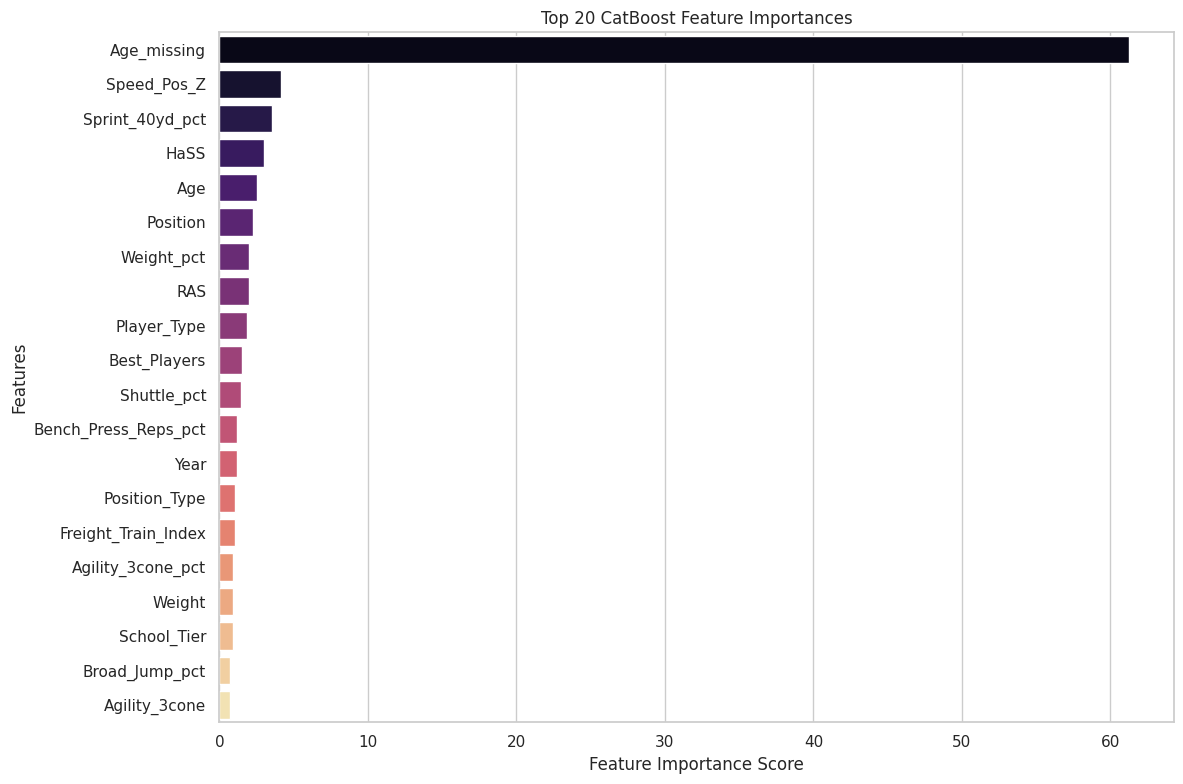

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained CatBoost model
feature_importances_cat = model_cat.get_feature_importance()

# Create a pandas Series for better visualization and sorting
importance_df_cat = pd.Series(feature_importances_cat, index=X.columns) # Corrected: use X_train.columns

# Sort the features by importance in descending order
sorted_importance_cat = importance_df_cat.sort_values(ascending=False)

print("Top 20 CatBoost Feature Importances:")
display(sorted_importance_cat.head(20))

# Optionally, visualize the top N features
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importance_cat.head(20).values, y=sorted_importance_cat.head(20).index, palette='magma')
plt.title('Top 20 CatBoost Feature Importances')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/catboost_feature_importance.png') # Save the feature importance plot to Google Drive
plt.show()

In [54]:
zero_importance_features = sorted_importance_cat[sorted_importance_cat == 0]

if not zero_importance_features.empty:
    print("Features with 0 importance:")
    display(zero_importance_features)
else:
    print("No features found with 0 importance.")

Features with 0 importance:


,0
School,0.0
Agility_3cone_missing,0.0
Sprint_40yd_missing,0.0
Vertical_Jump_missing,0.0
Bench_Press_Reps_missing,0.0
Broad_Jump_missing,0.0
